# Bidimensional FAEMD (FAEMD2D)

**FAEMD2D** applies Fast and Adaptive EMD to images / 2-D fields.  Instead of
surface spline envelopes (classical BEMD), it uses:

1. **8-neighbour extrema maps**;
2. **Delaunay nearest-neighbour distances** → adaptive odd window $w$;
3. **2-D order-statistics filters** + separable moving-average smoothing.

Multichannel images share one window estimated on $\sum H_i/\sqrt{n}$.

**Reference:** Thirumalaisamy & Ansell, IEEE SPL 2018; FA-MVEMD MATLAB toolbox.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from pysdkit import FAEMD2D
from pysdkit._faemd.filter import identify_max_min_2d, filter_size_2d, mean_envelope_2d

print(FAEMD2D())

Bidimensional Fast and Adaptive Empirical Mode Decomposition (FAEMD2D)


## 1. Synthetic textured image

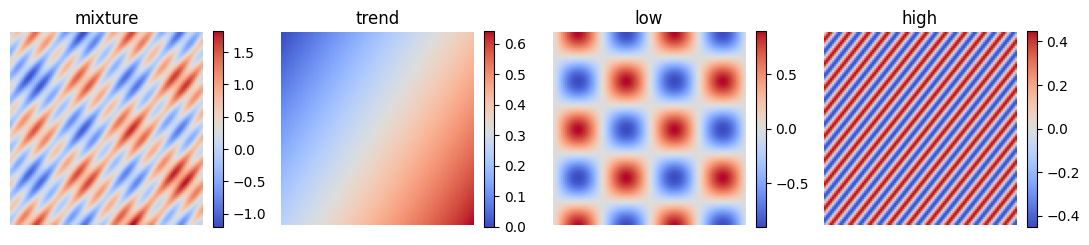

In [2]:
n = 96
yy, xx = np.mgrid[0:n, 0:n]
xx = xx / n
yy = yy / n

trend = 0.4 * xx + 0.25 * yy
low = 0.9 * np.sin(2 * np.pi * 2 * xx) * np.cos(2 * np.pi * 2 * yy)
high = 0.45 * np.sin(2 * np.pi * 10 * xx + 2 * np.pi * 8 * yy)
img = trend + low + high

fig, axes = plt.subplots(1, 4, figsize=(11, 2.8))
for ax, field, title in zip(
    axes, [img, trend, low, high], ["mixture", "trend", "low", "high"]
):
    im = ax.imshow(field, cmap="coolwarm")
    ax.set_title(title)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

## 2. Extrema map & adaptive window

d1..d7 = [ 7.  7. 13. 13.  9.  7.  7.] → selected 7


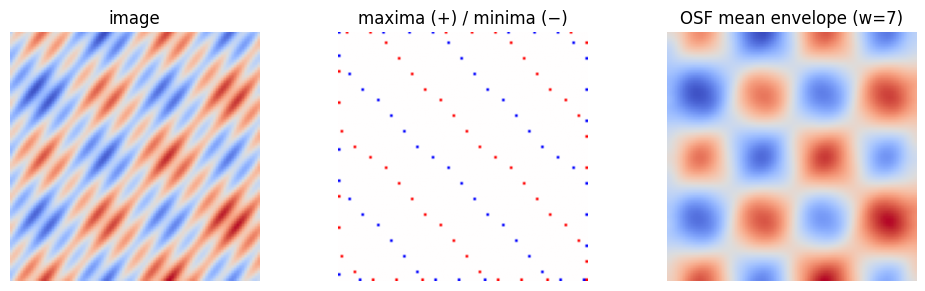

In [3]:
maxima, minima = identify_max_min_2d(img)
windows = filter_size_2d(maxima, minima, window_type=5)
w = int(windows[5])
print("d1..d7 =", windows, "→ selected", w)

mean_env = mean_envelope_2d(img, w)

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
axes[0].imshow(img, cmap="coolwarm")
axes[0].set_title("image")
axes[1].imshow(maxima.astype(float) - minima.astype(float), cmap="bwr")
axes[1].set_title("maxima (+) / minima (−)")
axes[2].imshow(mean_env, cmap="coolwarm")
axes[2].set_title(f"OSF mean envelope (w={w})")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Decomposition result

BIMFs shape: (4, 96, 96)
max |recon error|: 4.440892098500626e-16


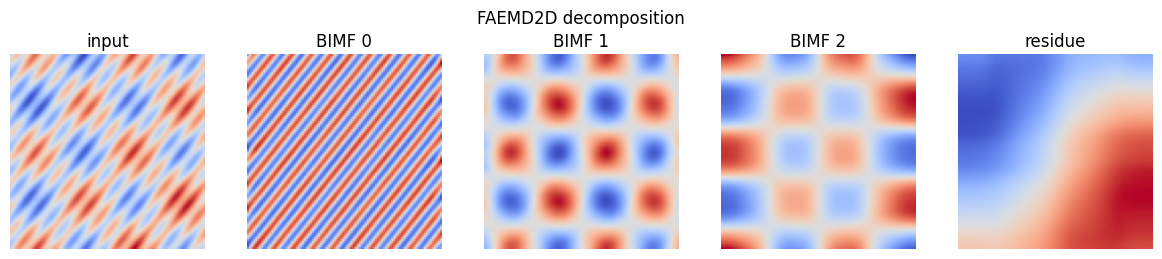

In [4]:
bimfs = FAEMD2D(max_imfs=4, tol=0.05, window_type=5).fit_transform(img)
print("BIMFs shape:", bimfs.shape)
print("max |recon error|:", np.max(np.abs(bimfs.sum(0) - img)))

K = bimfs.shape[0]
fig, axes = plt.subplots(1, K + 1, figsize=(2.4 * (K + 1), 2.6))
axes[0].imshow(img, cmap="coolwarm")
axes[0].set_title("input")
axes[0].axis("off")
for k in range(K):
    axes[k + 1].imshow(bimfs[k], cmap="coolwarm")
    axes[k + 1].set_title("residue" if k == K - 1 else f"BIMF {k}")
    axes[k + 1].axis("off")
plt.suptitle("FAEMD2D decomposition")
plt.tight_layout()
plt.show()

## 4. API

```python
from pysdkit import FAEMD2D

fa = FAEMD2D(max_imfs=4, tol=0.05, window_type=5)
BIMFs = fa.fit_transform(image)          # (K, H, W)
BIMFs = fa.fit_transform(channels)       # channels: (N, H, W) → (K, N, H, W)
```